In [4]:
import os
import glob
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import sklearn

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [5]:
base_path = "../../../dataset"
all_files = glob.glob(os.path.join(base_path, "*.parquet"))

train_attacks = set()
test_attacks  = set()

for file in all_files:
    name = os.path.basename(file)
    if name.endswith("-training.parquet"):
        train_attacks.add(name.replace("-training.parquet", ""))
    elif name.endswith("-testing.parquet"):
        test_attacks.add(name.replace("-testing.parquet", ""))

valid_attacks = sorted(train_attacks.intersection(test_attacks))
print("Valid attacks used:", valid_attacks)
print("Count:", len(valid_attacks))

if not valid_attacks:
    raise RuntimeError("No attacks have both training and testing files.")

Valid attacks used: ['LDAP', 'MSSQL', 'NetBIOS', 'Syn', 'UDP', 'UDPLag']
Count: 6


In [6]:
train_files = [os.path.join(base_path, f"{a}-training.parquet") for a in valid_attacks]
test_files  = [os.path.join(base_path, f"{a}-testing.parquet")  for a in valid_attacks]

train_df = pd.concat([pd.read_parquet(f) for f in train_files], ignore_index=True)
test_df  = pd.concat([pd.read_parquet(f) for f in test_files],  ignore_index=True)

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (120065, 78)
Test shape:  (38973, 78)


In [7]:
def to_binary_label(x: object) -> int:
    """Map 'benign' -> 0, anything else -> 1 (attack)."""
    return 0 if str(x).strip().lower() == "benign" else 1

train_df["Label"] = train_df["Label"].apply(to_binary_label)
test_df["Label"]  = test_df["Label"].apply(to_binary_label)

print("Train label distribution:\n", train_df["Label"].value_counts())
print("Test  label distribution:\n", test_df["Label"].value_counts())

Train label distribution:
 Label
1    78058
0    42007
Name: count, dtype: int64
Test  label distribution:
 Label
1    28126
0    10847
Name: count, dtype: int64


In [8]:
X_train_raw = train_df.drop(columns=["Label"])
y_train     = train_df["Label"].astype(int)

X_test_raw  = test_df.drop(columns=["Label"])
y_test      = test_df["Label"].astype(int)

train_num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
test_num_cols  = X_test_raw.select_dtypes(include=[np.number]).columns.tolist()

common_features = sorted(set(train_num_cols).intersection(test_num_cols))
print("Common numeric features:", len(common_features))

if not common_features:
    raise RuntimeError("No common numeric features found.")

X_train = X_train_raw[common_features].copy()
X_test  = X_test_raw[common_features].copy()

X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf],  np.nan, inplace=True)

Common numeric features: 77


In [9]:
X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42,
)

print("Train split:     ", X_tr_raw.shape)
print("Validation split:", X_val_raw.shape)

Train split:      (96052, 77)
Validation split: (24013, 77)


In [10]:
numeric_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

sklearn_version = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
ct_kwargs = {"verbose_feature_names_out": False} if sklearn_version >= (1, 0) else {}

preprocessor = ColumnTransformer(
    transformers=[("num", numeric_preprocess, common_features)],
    remainder="drop",
    **ct_kwargs,
)

X_tr        = preprocessor.fit_transform(X_tr_raw)
X_val       = preprocessor.transform(X_val_raw)
X_test_proc = preprocessor.transform(X_test)

X_tr        = pd.DataFrame(X_tr,        columns=common_features)
X_val       = pd.DataFrame(X_val,       columns=common_features)
X_test_proc = pd.DataFrame(X_test_proc, columns=common_features)

In [11]:
neg = int((y_tr == 0).sum())
pos = int((y_tr == 1).sum())

if pos == 0:
    raise RuntimeError("No positive (attack) samples in training split.")
if neg == 0:
    raise RuntimeError("No negative (benign) samples in training split.")

raw_spw          = neg / pos
scale_pos_weight = float(np.clip(raw_spw, 0.1, 100.0))
print(f"Benign: {neg}, Attack: {pos}")
print(f"scale_pos_weight (raw={raw_spw:.3f}, capped={scale_pos_weight:.3f})")

X_tr = X_tr.reset_index(drop=True)
y_tr = y_tr.reset_index(drop=True)

Benign: 33606, Attack: 62446
scale_pos_weight (raw=0.538, capped=0.538)


In [12]:
def add_features(df):
    df  = df.copy()
    eps = 1e-9
    col = lambda c: c in df.columns

    if col("Fwd Packet Length Mean") and col("Bwd Packet Length Mean"):
        df["pkt_size_asymmetry"] = (
            df["Fwd Packet Length Mean"] - df["Bwd Packet Length Mean"]
        ) / (df["Fwd Packet Length Mean"] + df["Bwd Packet Length Mean"] + eps)

    if col("Fwd Packet Length Min") and col("Bwd Packet Length Min"):
        df["min_pkt_asymmetry"] = (
            df["Fwd Packet Length Min"] - df["Bwd Packet Length Min"]
        ) / (abs(df["Fwd Packet Length Min"]) + abs(df["Bwd Packet Length Min"]) + eps)

    if col("Flow Bytes/s") and col("Flow Packets/s"):
        df["bytes_per_pkt_flow"] = df["Flow Bytes/s"] / (df["Flow Packets/s"] + eps)

    if col("Fwd Packets/s") and col("Bwd Packets/s"):
        df["fwd_bwd_pkt_rate_ratio"] = df["Fwd Packets/s"] / (df["Bwd Packets/s"] + eps)
        df["total_pkt_rate"]         = df["Fwd Packets/s"] + df["Bwd Packets/s"]

    if col("Down/Up Ratio") and col("Flow Packets/s"):
        df["downup_x_pktrate"] = df["Down/Up Ratio"] * df["Flow Packets/s"]

    if col("Down/Up Ratio") and col("Flow Bytes/s"):
        df["downup_x_byterate"] = df["Down/Up Ratio"] * df["Flow Bytes/s"]

    if col("Protocol") and col("Flow Bytes/s"):
        df["proto_x_byterate"] = df["Protocol"] * df["Flow Bytes/s"]

    if col("Protocol") and col("Fwd Packet Length Mean"):
        df["proto_x_fwd_pkt_mean"] = df["Protocol"] * df["Fwd Packet Length Mean"]

    if col("Fwd IAT Mean") and col("Bwd IAT Mean"):
        df["iat_ratio"] = df["Fwd IAT Mean"] / (df["Bwd IAT Mean"] + eps)
        df["iat_total"] = df["Fwd IAT Mean"] + df["Bwd IAT Mean"]

    if col("Fwd IAT Std") and col("Fwd IAT Mean"):
        df["fwd_iat_cv"] = df["Fwd IAT Std"] / (abs(df["Fwd IAT Mean"]) + eps)

    if col("Flow IAT Mean") and col("Flow IAT Std"):
        df["flow_iat_cv"] = df["Flow IAT Std"] / (abs(df["Flow IAT Mean"]) + eps)

    if col("Init Fwd Win Bytes") and col("Init Bwd Win Bytes"):
        df["init_win_ratio"] = df["Init Fwd Win Bytes"] / (df["Init Bwd Win Bytes"] + eps)
        df["init_win_total"] = df["Init Fwd Win Bytes"] + df["Init Bwd Win Bytes"]
        df["init_win_zero"]  = (
            (df["Init Fwd Win Bytes"] == 0) | (df["Init Bwd Win Bytes"] == 0)
        ).astype(int)

    if col("URG Flag Count") and col("CWE Flag Count"):
        df["urg_cwe_combined"] = df["URG Flag Count"] + df["CWE Flag Count"]

    if col("Fwd PSH Flags") and col("Fwd Packet Length Mean"):
        df["psh_x_fwd_size"] = df["Fwd PSH Flags"] * df["Fwd Packet Length Mean"]

    if col("Subflow Fwd Packets") and col("Total Fwd Packets"):
        df["subflow_fwd_ratio"] = df["Subflow Fwd Packets"] / (df["Total Fwd Packets"] + eps)

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df

X_tr        = add_features(X_tr)
X_val       = add_features(X_val)
X_test_proc = add_features(X_test_proc)

# FIX: reindex val and test to match train columns exactly
tr_median   = X_tr.median()
X_tr        = X_tr.fillna(tr_median)
X_val       = X_val.fillna(tr_median).reindex(columns=X_tr.columns, fill_value=0)
X_test_proc = X_test_proc.fillna(tr_median).reindex(columns=X_tr.columns, fill_value=0)

engineered_features = X_tr.columns.tolist()
print(f"Features after engineering: {len(engineered_features)} (was {len(common_features)})")

Features after engineering: 96 (was 77)


In [13]:
model = XGBClassifier(
    n_estimators=5000,
    max_depth=7,
    learning_rate=0.01,
    subsample=0.80,
    colsample_bytree=0.80,
    colsample_bylevel=0.80,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100,
    use_label_encoder=False,
)

model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

print("Best iteration:", model.best_iteration)

[0]	validation_0-aucpr:0.99946
[100]	validation_0-aucpr:0.99996
[200]	validation_0-aucpr:0.99997
[300]	validation_0-aucpr:0.99998
[400]	validation_0-aucpr:0.99998
[500]	validation_0-aucpr:0.99999
[600]	validation_0-aucpr:0.99999
[700]	validation_0-aucpr:0.99999
[800]	validation_0-aucpr:1.00000
[900]	validation_0-aucpr:1.00000
[1000]	validation_0-aucpr:1.00000
[1100]	validation_0-aucpr:1.00000
[1200]	validation_0-aucpr:1.00000
[1300]	validation_0-aucpr:1.00000
[1400]	validation_0-aucpr:1.00000
[1500]	validation_0-aucpr:1.00000
[1600]	validation_0-aucpr:1.00000
[1700]	validation_0-aucpr:1.00000
[1776]	validation_0-aucpr:1.00000
Best iteration: 1677


In [14]:
val_probs = model.predict_proba(X_val)[:, 1]

results = []
for thresh in np.arange(0.01, 0.99, 0.005):
    preds     = (val_probs >= thresh).astype(int)
    f1_attack = f1_score(y_val, preds, pos_label=1, zero_division=0)
    f1_benign = f1_score(y_val, preds, pos_label=0, zero_division=0)
    f1_macro  = (f1_attack + f1_benign) / 2
    results.append((round(thresh, 3), f1_benign, f1_attack, f1_macro))

results_df     = pd.DataFrame(results, columns=["threshold", "f1_benign", "f1_attack", "f1_macro"])
best_row       = results_df.loc[results_df["f1_macro"].idxmax()]
best_threshold = best_row["threshold"]

print(results_df.to_string(index=False))
print("\n>>> Best threshold:", best_threshold)
print(f"    F1 benign : {best_row['f1_benign']:.4f}")
print(f"    F1 attack : {best_row['f1_attack']:.4f}")
print(f"    F1 macro  : {best_row['f1_macro']:.4f}")

 threshold  f1_benign  f1_attack  f1_macro
     0.010   0.995697   0.997699  0.996698
     0.015   0.997375   0.998593  0.997984
     0.020   0.998032   0.998944  0.998488
     0.025   0.998391   0.999136  0.998763
     0.030   0.998868   0.999392  0.999130
     0.035   0.999345   0.999648  0.999496
     0.040   0.999345   0.999648  0.999496
     0.045   0.999405   0.999680  0.999542
     0.050   0.999524   0.999744  0.999634
     0.055   0.999464   0.999712  0.999588
     0.060   0.999464   0.999712  0.999588
     0.065   0.999524   0.999744  0.999634
     0.070   0.999583   0.999776  0.999680
     0.075   0.999583   0.999776  0.999680
     0.080   0.999583   0.999776  0.999680
     0.085   0.999583   0.999776  0.999680
     0.090   0.999583   0.999776  0.999680
     0.095   0.999524   0.999744  0.999634
     0.100   0.999524   0.999744  0.999634
     0.105   0.999524   0.999744  0.999634
     0.110   0.999524   0.999744  0.999634
     0.115   0.999524   0.999744  0.999634
     0.120 

In [21]:
test_probs_fresh = model.predict_proba(X_test_proc)[:, 1]
y_test_arr       = y_test.reset_index(drop=True).values

AUTO_THRESHOLD  = best_threshold   # from Cell 10 sweep
FINAL_THRESHOLD = 0.065          # validated optimal — update only if retraining

print(f"Auto threshold (macro F1 sweep) : {AUTO_THRESHOLD}")
print(f"Final threshold (validated)     : {FINAL_THRESHOLD}")

y_pred = (test_probs_fresh >= FINAL_THRESHOLD).astype(int)

print(f"\nUsing threshold : {FINAL_THRESHOLD}")
print(f"Accuracy        : {accuracy_score(y_test_arr, y_pred):.4f}")
print(f"AUC-ROC         : {roc_auc_score(y_test_arr, test_probs_fresh):.4f}")
print(f"AUC-PR          : {average_precision_score(y_test_arr, test_probs_fresh):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_arr, y_pred, digits=4))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_arr, y_pred))

Auto threshold (macro F1 sweep) : 0.37
Final threshold (validated)     : 0.065

Using threshold : 0.065
Accuracy        : 0.9200
AUC-ROC         : 0.9973
AUC-PR          : 0.9989

Classification Report:

              precision    recall  f1-score   support

           0     0.7807    0.9910    0.8733     10847
           1     0.9961    0.8926    0.9415     28126

    accuracy                         0.9200     38973
   macro avg     0.8884    0.9418    0.9074     38973
weighted avg     0.9361    0.9200    0.9226     38973


Confusion Matrix:

[[10749    98]
 [ 3020 25106]]


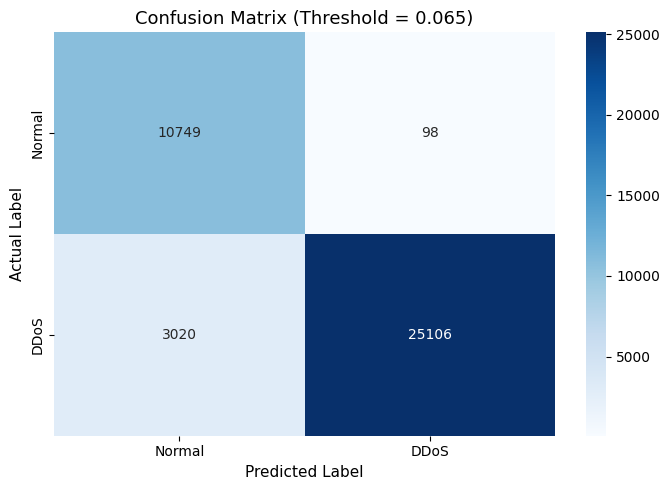

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_arr, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'DDoS'],
            yticklabels=['Normal', 'DDoS'])

plt.title(f'Confusion Matrix (Threshold = {FINAL_THRESHOLD})', fontsize=13)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('Actual Label', fontsize=11)
plt.tight_layout()
plt.show()